In [1]:
import numpy as np
from InfAdjFPFiniteDiffApp import InfAdjFPFiniteDiff

In [2]:
dim = 1
v0 = 1

def infPotFunc(phi):
    return v0

def infPotDerivFunc(phi):
    return 0

infPotentialDerivFuncs = [infPotDerivFunc]

nGrid = 256
upperBound = 1.0
lowerBound = 0.0
upperBoundCond = "Neumann0"
lowerBoundCond = "Dirichlet"

In [3]:
fpFinDiff = InfAdjFPFiniteDiff(
    dim,
    infPotFunc,
    infPotentialDerivFuncs,
    [nGrid],
    [upperBound],
    [lowerBound],
    [upperBoundCond],
    [lowerBoundCond]
)

In [4]:
fpFinDiff

array([[-562.02860566,  281.01430283,    0.        , ...,    0.        ,
           0.        ,    0.        ],
       [ 281.01430283, -562.02860566,  281.01430283, ...,    0.        ,
           0.        ,    0.        ],
       [   0.        ,  281.01430283, -562.02860566, ...,    0.        ,
           0.        ,    0.        ],
       ...,
       [   0.        ,    0.        ,    0.        , ..., -562.02860566,
         281.01430283,    0.        ],
       [   0.        ,    0.        ,    0.        , ...,  281.01430283,
        -562.02860566,  281.01430283],
       [   0.        ,    0.        ,    0.        , ...,    0.        ,
         562.02860566, -562.02860566]])

In [26]:
eigVals, eigVecs = np.linalg.eig(fpFinDiff)
negEigVals = -eigVals
eigVecsSort = eigVecs.T[np.argsort(negEigVals)]
negEigValsSort = np.sort(negEigVals)

In [6]:
import matplotlib.pyplot as plt

In [7]:
#negEigVals = np.sort(-eigVals)
eigValsTh = [np.pi ** 2 * v0 / (24 * np.pi ** 2) / (upperBound - lowerBound) * (n + 0.5) ** 2 for n in range(nGrid)]

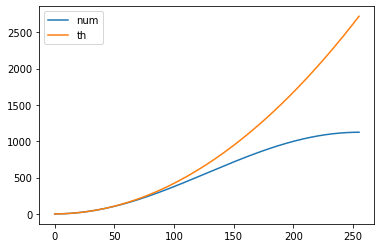

In [21]:
ax = plt.gca()
plt.plot(np.arange(nGrid), negEigValsSort, label = "num")
plt.plot(np.arange(nGrid), eigValsTh, label = "th")
plt.legend()
plt.show()

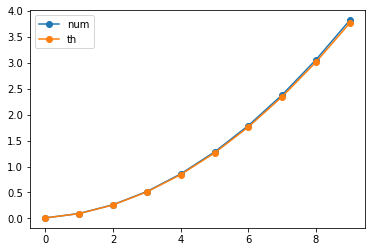

In [23]:
ax = plt.gca()
plt.plot(np.arange(10), negEigValsSort[:10], marker='o', label = "num")
plt.plot(np.arange(10), eigValsTh[:10], marker='o', label = "th")
plt.legend()
plt.show()

考えている$\phi$の領域をちょうど覆うようなGaussianを試行ベクトルに取り、固有ベクトルで展開

In [24]:
grids = np.flip(np.linspace(upperBound, lowerBound, nGrid, endpoint=False))
sigma = (upperBound - lowerBound) / 6.0
trialVec = np.exp(- 0.5 * ((grids - 0.5 * (upperBound + lowerBound)) / sigma) ** 2)
trialVec /= np.linalg.norm(trialVec)

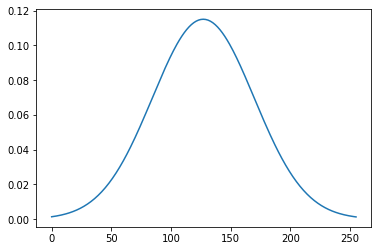

In [25]:
ax = plt.gca()
plt.plot(trialVec)
plt.show()

In [27]:
contriEachEigVec = [np.dot(trialVec, ev) ** 2 for ev in eigVecsSort]

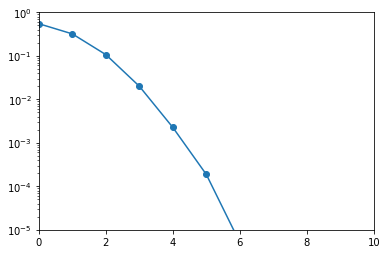

In [30]:
ax = plt.gca()
plt.plot(np.arange(nGrid), contriEachEigVec, marker='o')
plt.yscale('log')
ax.set_xlim(0, 10)
ax.set_ylim(1e-5, 1)
plt.show()

境界のせいで、微分演算子を離散化して得られた行列はエルミートでなくなっているから、固有ベクトルは正規直交基底ではない。

ゆえに↑の寄与度のグラフは厳密には正しくない

論文の上では厳密に議論しなきゃ！